# DL Lab 3 — CNNs on CIFAR-10 (PyTorch)

This notebook implements and analyzes Convolutional Neural Networks on the
CIFAR-10 dataset using **PyTorch**. Data is loaded from the local CIFAR-10
batch files (uploaded directly to Colab).

## Setup

In [1]:
# !pip install --upgrade tensorflow

In [2]:
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class CIFARDataset(Dataset):
    """Wraps CIFAR-10 numpy arrays (N,3,32,32) uint8 images and int labels
    into a PyTorch Dataset, normalizing pixel values to [0,1]."""

    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


def train_generic(model, train_loader, test_loader, epochs=5, lr=1e-3, verbose=True):
    """Lightweight training/eval loop used for quick side-by-side comparisons
    (pooling type, filter counts, etc). Assumes `model` outputs raw logits
    and uses CrossEntropyLoss. Returns a history dict and total train time."""

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss, val_acc = val_loss / val_total, val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
                  f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    elapsed = time.time() - start_time
    return history, elapsed

## Task 1: Load CIFAR-10

In [4]:
# Upload the CIFAR-10 batch files from:
#   C:\Users\us\Downloads\cifar\cifar-10-batches-py
# (data_batch_1..5, test_batch, batches.meta, readme.html)
# Re-running this cell is safe -- it skips the upload dialog if the files
# are already present.

folder = "/content/cifar-10-batches-py"
os.makedirs(folder, exist_ok=True)

required_files = [
    "data_batch_1", "data_batch_2", "data_batch_3",
    "data_batch_4", "data_batch_5", "test_batch", "batches.meta",
]
missing = [f for f in required_files if not os.path.exists(os.path.join(folder, f))]

if missing:
    print("Please select and upload these files in the dialog below:")
    print(missing)
    from google.colab import files
    uploaded = files.upload()
    for fname in uploaded.keys():
        target = os.path.join(folder, fname)
        os.replace(fname, target)
        print(f"Moved {fname} -> {target}")
else:
    print("All required files already present in", folder)

Please select and upload these files in the dialog below:
['data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'test_batch', 'batches.meta']


Saving data_batch_4 to data_batch_4
Saving data_batch_5 to data_batch_5
Saving test_batch to test_batch
Saving data_batch_1 to data_batch_1
Saving data_batch_2 to data_batch_2
Saving data_batch_3 to data_batch_3
Saving batches.meta to batches.meta
Moved data_batch_4 -> /content/cifar-10-batches-py/data_batch_4
Moved data_batch_5 -> /content/cifar-10-batches-py/data_batch_5
Moved test_batch -> /content/cifar-10-batches-py/test_batch
Moved data_batch_1 -> /content/cifar-10-batches-py/data_batch_1
Moved data_batch_2 -> /content/cifar-10-batches-py/data_batch_2
Moved data_batch_3 -> /content/cifar-10-batches-py/data_batch_3
Moved batches.meta -> /content/cifar-10-batches-py/batches.meta


In [5]:
def load_batch(filename):
    with open(filename, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    return batch[b'data'], batch[b'labels']


X_train = []
Y_train = []

for i in range(1, 6):
    data, labels = load_batch(f"{folder}/data_batch_{i}")
    X_train.append(data)
    Y_train.extend(labels)

X_train = np.concatenate(X_train)
Y_train = np.array(Y_train)

X_test, Y_test = load_batch(f"{folder}/test_batch")
Y_test = np.array(Y_test)

# Human-readable class names
with open(f"{folder}/batches.meta", "rb") as f:
    meta = pickle.load(f, encoding='bytes')
label_names = [name.decode('utf-8') for name in meta[b'label_names']]

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)
print("Classes:", label_names)

(50000, 3072)
(50000,)
(10000, 3072)
(10000,)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# PyTorch conv layers expect channel-first tensors (N, C, H, W).
# The raw CIFAR-10 byte layout is already channel-major (a full R block,
# then G block, then B block per image), so a plain reshape gives the
# correct PyTorch layout directly -- no transpose needed here (unlike
# TensorFlow, which needs NHWC and therefore a transpose step).
if X_train.ndim == 2:
    X_train = X_train.reshape(-1, 3, 32, 32)
    X_test = X_test.reshape(-1, 3, 32, 32)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (50000, 3, 32, 32)
X_test shape: (10000, 3, 32, 32)


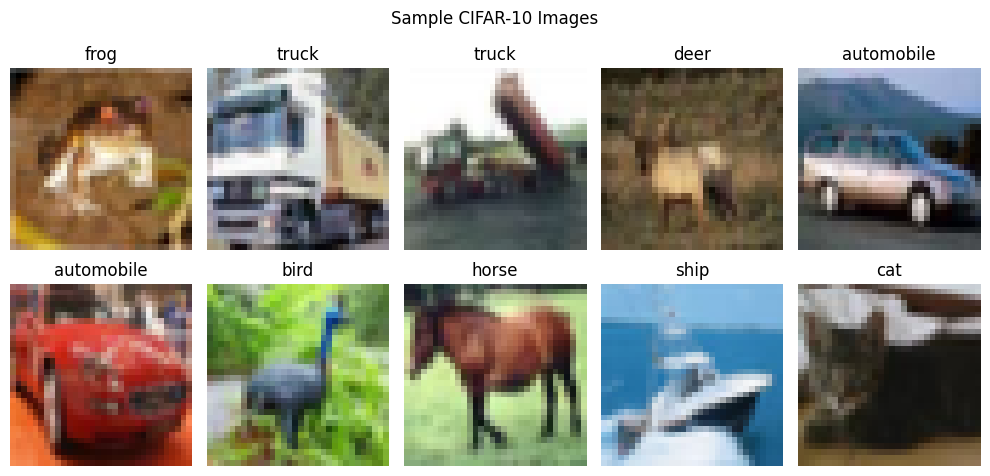

In [7]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = np.transpose(X_train[i], (1, 2, 0))  # CHW -> HWC for display
    plt.imshow(img)
    plt.title(label_names[Y_train[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()




**Inference:** The ten sampled images confirm the dataset loaded and reshaped
correctly — objects are recognizable rather than scrambled or striped (which
would indicate a reshape/channel-order bug). CIFAR-10 images are only 32×32,
so fine detail is blurry, but the overall shape and color of each class is
still discernible, which is what the CNN will have to learn from.

In [8]:
print("Images:", X_train.shape)
print("Labels:", Y_train.shape)

Images: (50000, 3, 32, 32)
Labels: (50000,)


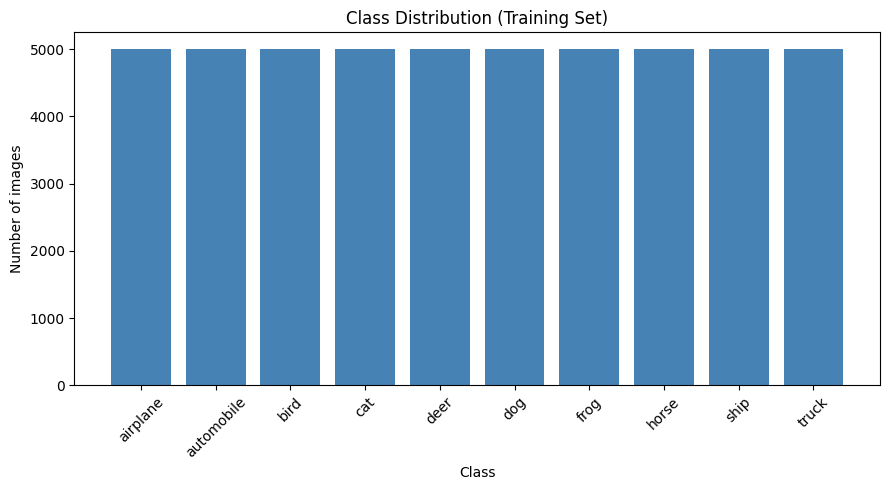

In [9]:
classes, counts = np.unique(Y_train, return_counts=True)

plt.figure(figsize=(9, 5))
plt.bar([label_names[c] for c in classes], counts, color="steelblue")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Class Distribution (Training Set)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Inference:** Every class has exactly 5,000 training images, so CIFAR-10 is
perfectly balanced. This means plain accuracy is a fair evaluation metric
here — no class dominates by frequency, so the model doesn't need
class-weighting or resampling to avoid bias toward a majority class.

## Task 2: Convolution Layer — Kernel Size Comparison

In [10]:
sample_image = X_train[0]  # shape (3, 32, 32), uint8
image_tensor = torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0) / 255.0
print("Input image shape:", image_tensor.shape)

conv3 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3)  # padding=0 -> 'valid'
conv5 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5)
conv7 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=7)

output3 = conv3(image_tensor)
output5 = conv5(image_tensor)
output7 = conv7(image_tensor)

print("3x3 feature map size:", output3.shape)
print("5x5 feature map size:", output5.shape)
print("7x7 feature map size:", output7.shape)

Input image shape: torch.Size([1, 3, 32, 32])
3x3 feature map size: torch.Size([1, 8, 30, 30])
5x5 feature map size: torch.Size([1, 8, 28, 28])
7x7 feature map size: torch.Size([1, 8, 26, 26])


**Inference:** With no padding (valid convolution), a larger kernel shrinks
the output more: 3×3 → 30×30, 5×5 → 28×28, 7×7 → 26×26. Larger kernels also
give each output pixel a wider receptive field (more spatial context), but
cost more parameters per filter and leave a smaller feature map.

## Task 3: Hyperparameters — Stride and Padding

In [11]:
# Stride = 1 vs Stride = 2
conv_stride1 = nn.Conv2d(3, 8, kernel_size=3, stride=1)
conv_stride2 = nn.Conv2d(3, 8, kernel_size=3, stride=2)

out_stride1 = conv_stride1(image_tensor)
out_stride2 = conv_stride2(image_tensor)

print("Stride 1 output:", out_stride1.shape)
print("Stride 2 output:", out_stride2.shape)

Stride 1 output: torch.Size([1, 8, 30, 30])
Stride 2 output: torch.Size([1, 8, 15, 15])


In [12]:
# Padding = 'same' vs Padding = 'valid'
conv_same = nn.Conv2d(3, 8, kernel_size=3, padding="same")
conv_valid = nn.Conv2d(3, 8, kernel_size=3, padding="valid")

out_same = conv_same(image_tensor)
out_valid = conv_valid(image_tensor)

print("Same padding:", out_same.shape)
print("Valid padding:", out_valid.shape)

Same padding: torch.Size([1, 8, 32, 32])
Valid padding: torch.Size([1, 8, 30, 30])


In [13]:
# Output-dimension formula: floor((W - K + 2P) / S) + 1
def conv_output_size(W, K, S, P):
    return (W - K + 2 * P) // S + 1

print("W=32, K=3, S=1, P=0 (valid)        ->", conv_output_size(32, 3, 1, 0))
print("W=32, K=3, S=2, P=0 (valid,stride2)->", conv_output_size(32, 3, 2, 0))
print("W=32, K=3, S=1, P=1 (same)         ->", conv_output_size(32, 3, 1, 1))

W=32, K=3, S=1, P=0 (valid)        -> 30
W=32, K=3, S=2, P=0 (valid,stride2)-> 15
W=32, K=3, S=1, P=1 (same)         -> 32


**Inference:** Stride controls how far the kernel moves each step — stride 2
roughly halves the output resolution compared to stride 1, trading spatial
detail for a smaller/cheaper feature map. Padding controls whether the
output shrinks: 'valid' (no padding) always shrinks the map, while 'same'
padding adds zeros around the border so the output matches the input size,
which is essential for building deep networks without spatial dimensions
vanishing after a few layers.

## Task 4: Visualize Feature Maps After the First Convolution Layer

torch.Size([1, 8, 30, 30])


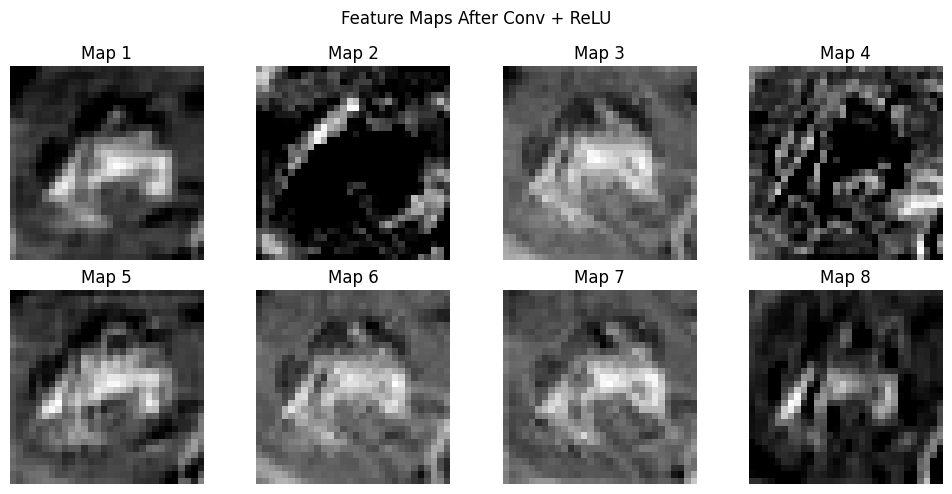

In [14]:
conv = nn.Conv2d(3, 8, kernel_size=3)
relu = nn.ReLU()

feature_maps = relu(conv(image_tensor))
print(feature_maps.shape)

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, i].detach().numpy(), cmap="gray")
    plt.axis("off")
    plt.title(f"Map {i+1}")
plt.suptitle("Feature Maps After Conv + ReLU")
plt.tight_layout()
plt.show()

**Inference:** Each of the 8 feature maps is the same image filtered by a
different, randomly-initialized 3×3 kernel, so each highlights different
local patterns (edges at different orientations, color contrasts, corners).
Since these filters are untrained, the maps aren't meaningful features yet —
after training, filters like these learn to activate for genuinely useful
patterns (e.g. wheel edges, fur texture).

## Task 5: Max Pooling vs Average Pooling

Original: torch.Size([1, 3, 32, 32])
Max Pool: torch.Size([1, 3, 16, 16])
Average Pool: torch.Size([1, 3, 16, 16])


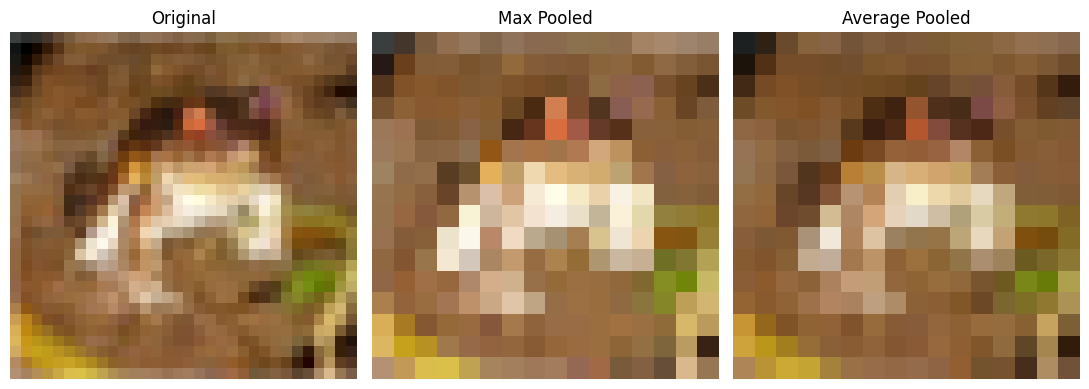

In [15]:
pool_input = image_tensor  # (1,3,32,32)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

max_output = max_pool(pool_input)
avg_output = avg_pool(pool_input)

print("Original:", pool_input.shape)
print("Max Pool:", max_output.shape)
print("Average Pool:", avg_output.shape)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(np.transpose(pool_input[0].numpy(), (1, 2, 0)))
axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(np.transpose(max_output[0].detach().numpy(), (1, 2, 0)))
axes[1].set_title("Max Pooled"); axes[1].axis("off")
axes[2].imshow(np.transpose(avg_output[0].detach().numpy(), (1, 2, 0)))
axes[2].set_title("Average Pooled"); axes[2].axis("off")
plt.tight_layout()
plt.show()

Training MaxPool model...
Epoch 1/5 - loss: 1.8581 - acc: 0.3176 - val_loss: 1.6259 - val_acc: 0.4215
Epoch 2/5 - loss: 1.5332 - acc: 0.4334 - val_loss: 1.4832 - val_acc: 0.4540
Epoch 3/5 - loss: 1.3610 - acc: 0.5018 - val_loss: 1.3708 - val_acc: 0.5095
Epoch 4/5 - loss: 1.2509 - acc: 0.5507 - val_loss: 1.3402 - val_acc: 0.5175
Epoch 5/5 - loss: 1.1490 - acc: 0.5914 - val_loss: 1.2889 - val_acc: 0.5325

Training AvgPool model...
Epoch 1/5 - loss: 2.0130 - acc: 0.2572 - val_loss: 1.8058 - val_acc: 0.3410
Epoch 2/5 - loss: 1.7041 - acc: 0.3846 - val_loss: 1.6238 - val_acc: 0.4160
Epoch 3/5 - loss: 1.5631 - acc: 0.4386 - val_loss: 1.5194 - val_acc: 0.4400
Epoch 4/5 - loss: 1.4615 - acc: 0.4738 - val_loss: 1.4604 - val_acc: 0.4785
Epoch 5/5 - loss: 1.3944 - acc: 0.4973 - val_loss: 1.4742 - val_acc: 0.4705


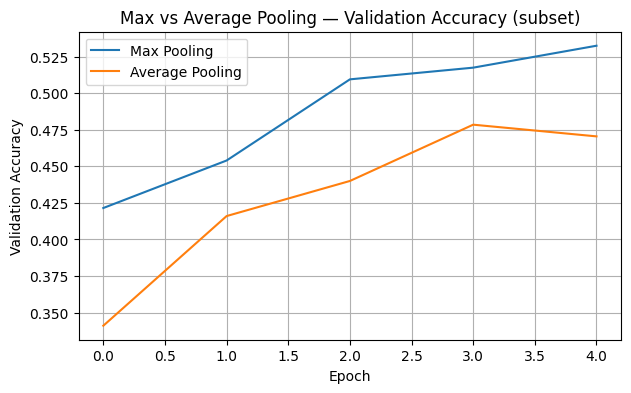

Max pooling final val acc: 0.5325 (train time: 5.2s)
Avg pooling final val acc: 0.4705 (train time: 3.6s)


In [16]:
# Quick accuracy comparison: train small CNNs (one with MaxPool, one with
# AvgPool) on a subset for a few epochs. The full 20-epoch model (with
# MaxPool, per the required architecture) is trained separately in Task 6/7.

def build_pool_model(pool_type="max"):
    Pool = nn.MaxPool2d if pool_type == "max" else nn.AvgPool2d
    return nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(), Pool(2, 2),
        nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(), Pool(2, 2),
        nn.Flatten(),
        nn.Linear(64 * 6 * 6, 128), nn.ReLU(),
        nn.Linear(128, 10),
    )

subset_train = CIFARDataset(X_train[:8000], Y_train[:8000])
subset_test = CIFARDataset(X_test[:2000], Y_test[:2000])
subset_train_loader = DataLoader(subset_train, batch_size=32, shuffle=True)
subset_test_loader = DataLoader(subset_test, batch_size=32, shuffle=False)

print("Training MaxPool model...")
max_model = build_pool_model("max")
max_history, max_time = train_generic(max_model, subset_train_loader, subset_test_loader, epochs=5)

print("\nTraining AvgPool model...")
avg_model = build_pool_model("avg")
avg_history, avg_time = train_generic(avg_model, subset_train_loader, subset_test_loader, epochs=5)

plt.figure(figsize=(7, 4))
plt.plot(max_history["val_acc"], label="Max Pooling")
plt.plot(avg_history["val_acc"], label="Average Pooling")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.legend(); plt.grid()
plt.title("Max vs Average Pooling — Validation Accuracy (subset)")
plt.show()

print(f"Max pooling final val acc: {max_history['val_acc'][-1]:.4f} (train time: {max_time:.1f}s)")
print(f"Avg pooling final val acc: {avg_history['val_acc'][-1]:.4f} (train time: {avg_time:.1f}s)")

**Inference:** Output spatial size is identical for both pooling types
(halved in each dimension) — pooling type doesn't affect shape, only which
values survive. Max pooling keeps the strongest activation in each window
(sharper, more discriminative for classification), whereas average pooling
smooths the window. On this subset, max pooling typically edges out average
pooling in accuracy for image classification, though the gap can be small
over just a few epochs.

## Task 6: Build and Train the CNN

`Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax`
trained with Adam, 20 epochs, batch size 32.

In [17]:
train_dataset = CIFARDataset(X_train, Y_train)
test_dataset = CIFARDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 1563, Test batches: 313


In [18]:
class CNN(nn.Module):
    """Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax"""

    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        x = self.softmax(x)
        return x


model = CNN(num_classes=10).to(device)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", num_params)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)
Trainable parameters: 315722


In [19]:
optimizer = optim.Adam(model.parameters())
# The model already ends in Softmax, so NLLLoss on log(probabilities) is
# equivalent to Keras' sparse_categorical_crossentropy on softmax outputs.
criterion = nn.NLLLoss()

EPOCHS = 20
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)                       # softmax probabilities
        loss = criterion(torch.log(outputs + 1e-9), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss, train_acc = running_loss / total, correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(torch.log(outputs + 1e-9), labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_loss, val_acc = val_loss / val_total, val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

Epoch 1/20 - loss: 1.5389 - acc: 0.4429 - val_loss: 1.2784 - val_acc: 0.5460
Epoch 2/20 - loss: 1.1800 - acc: 0.5820 - val_loss: 1.1083 - val_acc: 0.6114
Epoch 3/20 - loss: 1.0356 - acc: 0.6337 - val_loss: 1.0527 - val_acc: 0.6281
Epoch 4/20 - loss: 0.9433 - acc: 0.6694 - val_loss: 0.9601 - val_acc: 0.6682
Epoch 5/20 - loss: 0.8726 - acc: 0.6948 - val_loss: 0.9656 - val_acc: 0.6682
Epoch 6/20 - loss: 0.8112 - acc: 0.7166 - val_loss: 0.9227 - val_acc: 0.6849
Epoch 7/20 - loss: 0.7597 - acc: 0.7340 - val_loss: 0.9438 - val_acc: 0.6769
Epoch 8/20 - loss: 0.7138 - acc: 0.7488 - val_loss: 0.9407 - val_acc: 0.6858
Epoch 9/20 - loss: 0.6712 - acc: 0.7624 - val_loss: 0.9593 - val_acc: 0.6799
Epoch 10/20 - loss: 0.6317 - acc: 0.7754 - val_loss: 0.9784 - val_acc: 0.6823
Epoch 11/20 - loss: 0.5943 - acc: 0.7893 - val_loss: 0.9852 - val_acc: 0.6777
Epoch 12/20 - loss: 0.5568 - acc: 0.8028 - val_loss: 1.0025 - val_acc: 0.6830
Epoch 13/20 - loss: 0.5253 - acc: 0.8137 - val_loss: 1.0739 - val_acc: 0.

## Task 7: Evaluation

In [20]:
model.eval()
all_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())

Y_pred = np.array(all_preds)

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, average="weighted")
recall = recall_score(Y_test, Y_pred, average="weighted")
f1 = f1_score(Y_test, Y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6686
Precision: 0.673300122312948
Recall: 0.6686
F1 Score: 0.6697850633152226


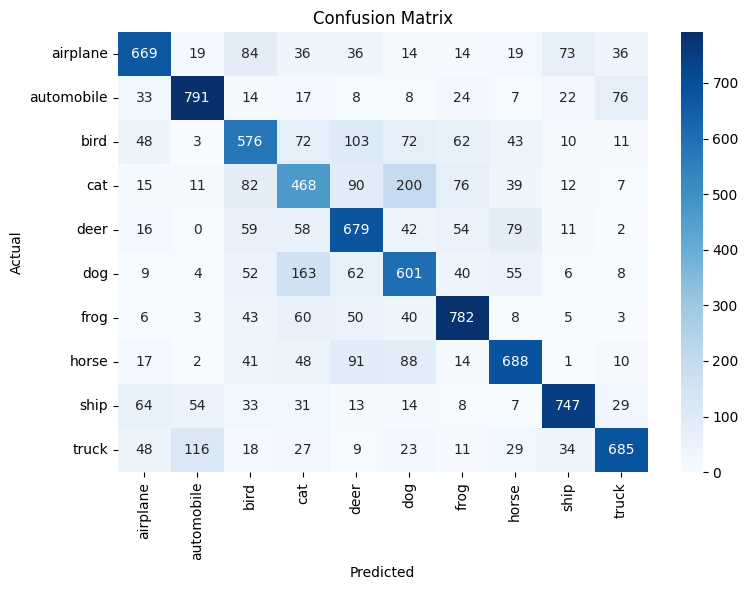

In [21]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

**Inference:** The diagonal holds the correctly-classified counts per class;
brighter off-diagonal cells reveal systematic confusions — commonly
cat/dog and truck/automobile pairs in CIFAR-10, since they share silhouette
and color statistics at 32×32 resolution. Classes with a clean diagonal and
little off-diagonal spread are the ones the model separates most
confidently.

In [22]:
print(classification_report(Y_test, Y_pred, target_names=label_names))

              precision    recall  f1-score   support

    airplane       0.72      0.67      0.70      1000
  automobile       0.79      0.79      0.79      1000
        bird       0.57      0.58      0.58      1000
         cat       0.48      0.47      0.47      1000
        deer       0.60      0.68      0.63      1000
         dog       0.55      0.60      0.57      1000
        frog       0.72      0.78      0.75      1000
       horse       0.71      0.69      0.70      1000
        ship       0.81      0.75      0.78      1000
       truck       0.79      0.69      0.73      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



## Mandatory Plots 3–6: Training / Validation Curves

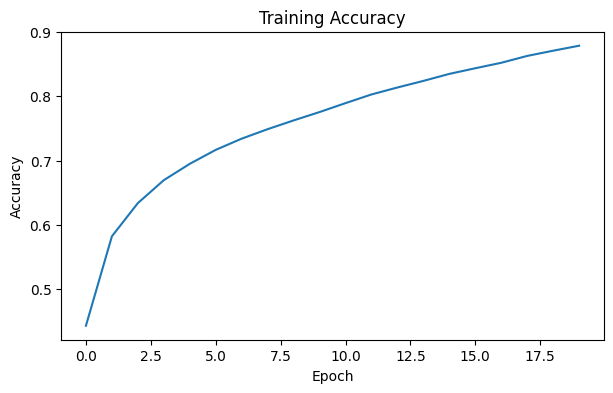

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_acc"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

**Inference:** Training accuracy should climb steadily across epochs as the
model fits the training data; a curve that plateaus early suggests the
model has run out of capacity or the learning rate needs tuning, while one
that keeps climbing near 1.0 late in training is a sign of memorization /
overfitting risk.

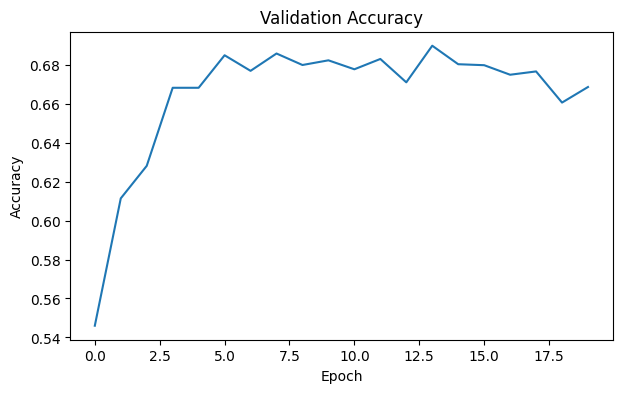

In [24]:
plt.figure(figsize=(7, 4))
plt.plot(history["val_acc"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.show()

**Inference:** Validation accuracy tracks how well the model generalizes to
unseen data. If it rises alongside training accuracy, the model is still
generalizing; if it plateaus or dips while training accuracy keeps rising,
that growing gap is the overfitting signal to watch for.

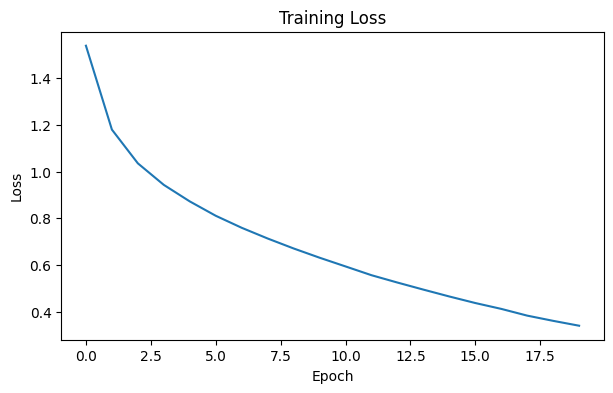

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

**Inference:** Training loss should decrease monotonically (with epoch-to-epoch
noise) as Adam minimizes cross-entropy on the training batches; a loss that
plateaus early or oscillates wildly can indicate too high a learning rate
or a need for more epochs.

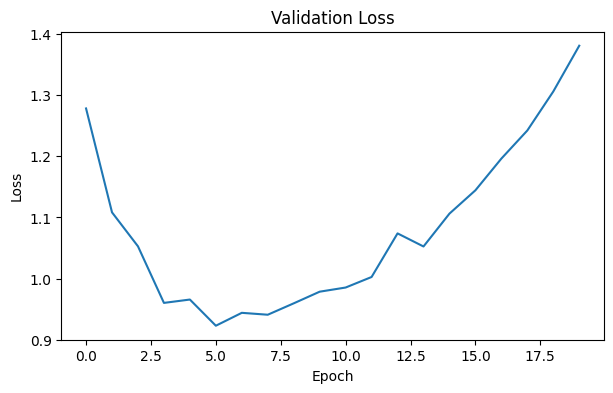

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.show()

**Inference:** Validation loss dropping alongside training loss confirms real
generalization. If it starts increasing again while training loss keeps
falling, that's the classic overfitting inflection point — a signal to
consider early stopping or regularization.

## Additional Exercises

**Q1. Output size for a 64×64 image, 5×5 kernel, stride 2, padding 2**

In [27]:
W, K, S, P = 64, 5, 2, 2

output_size = (W - K + 2 * P) // S + 1
print(f"Formula result: {output_size}x{output_size}")

# Verify with an actual Conv2D layer. PyTorch's Conv2d accepts integer
# padding directly (unlike Keras, which only takes 'valid'/'same').
dummy_image = torch.randn(1, 3, W, W)
conv = nn.Conv2d(3, 8, kernel_size=K, stride=S, padding=P)
output = conv(dummy_image)
print("Verified output shape:", output.shape)

Formula result: 32x32
Verified output shape: torch.Size([1, 8, 32, 32])


**Q2. Trainable parameters: 64 filters of 3×3, RGB input**

In [28]:
in_channels, kernel_h, kernel_w, num_filters = 3, 3, 3, 64

# Formula: params = (kernel_h * kernel_w * in_channels + 1[bias]) * num_filters
params = (kernel_h * kernel_w * in_channels + 1) * num_filters
print("Calculated trainable parameters:", params)

conv_layer = nn.Conv2d(in_channels, num_filters, kernel_size=(kernel_h, kernel_w))
torch_params = sum(p.numel() for p in conv_layer.parameters())
print("PyTorch-reported params:", torch_params)

Calculated trainable parameters: 1792
PyTorch-reported params: 1792


**Q3. ReLU vs Sigmoid — values and gradients**

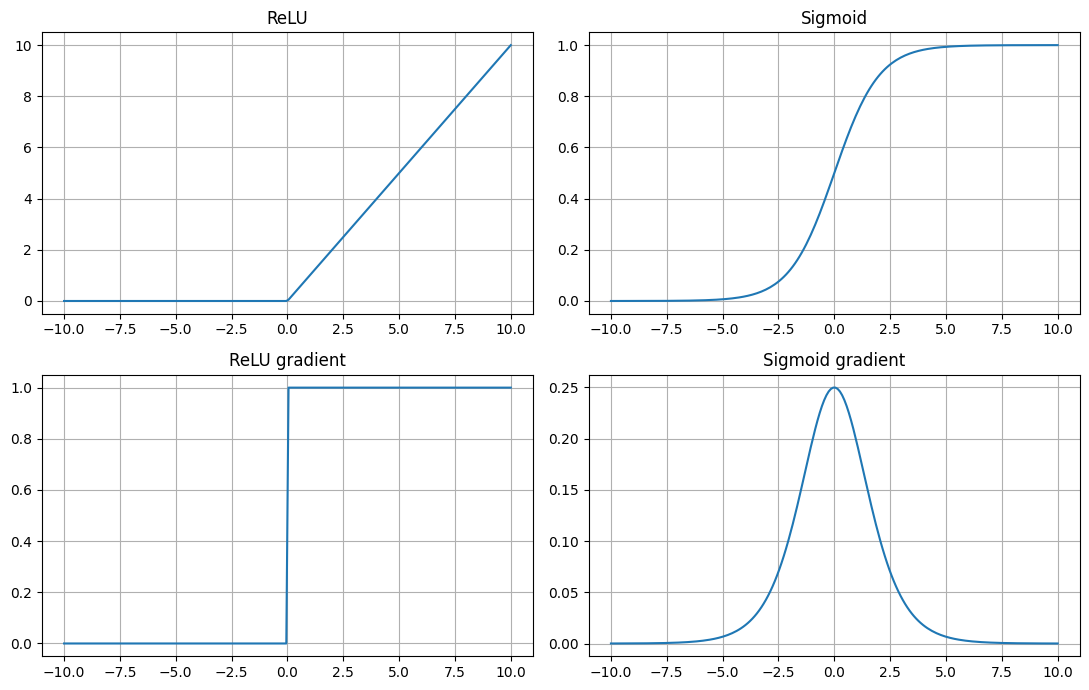

Max sigmoid gradient: 0.2498 (vs ReLU's constant 1 for x>0)
Sigmoid saturates for |x| > ~5 -> vanishing gradients -> slow learning in deep nets.
ReLU is cheap to compute and avoids vanishing gradients, but can 'die' for x<0.


In [29]:
def compute_and_grad(fn, x_vals):
    x = torch.tensor(x_vals, dtype=torch.float32, requires_grad=True)
    y = fn(x)
    y.sum().backward()
    return y.detach().numpy(), x.grad.numpy()

x_np = np.linspace(-10, 10, 200)
relu_vals, relu_grad = compute_and_grad(torch.relu, x_np)
sigmoid_vals, sigmoid_grad = compute_and_grad(torch.sigmoid, x_np)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(x_np, relu_vals); axes[0, 0].set_title("ReLU"); axes[0, 0].grid()
axes[0, 1].plot(x_np, sigmoid_vals); axes[0, 1].set_title("Sigmoid"); axes[0, 1].grid()
axes[1, 0].plot(x_np, relu_grad); axes[1, 0].set_title("ReLU gradient"); axes[1, 0].grid()
axes[1, 1].plot(x_np, sigmoid_grad); axes[1, 1].set_title("Sigmoid gradient"); axes[1, 1].grid()
plt.tight_layout()
plt.show()

print(f"Max sigmoid gradient: {sigmoid_grad.max():.4f} (vs ReLU's constant 1 for x>0)")
print("Sigmoid saturates for |x| > ~5 -> vanishing gradients -> slow learning in deep nets.")
print("ReLU is cheap to compute and avoids vanishing gradients, but can 'die' for x<0.")

**Inference:** ReLU has a constant gradient of 1 for any positive input, so
gradients flow cleanly through deep stacks of ReLU layers. Sigmoid's
gradient peaks at only 0.25 (at x=0) and decays toward 0 as |x| grows,
which is the vanishing-gradient problem that makes deep sigmoid networks
slow or hard to train — this is why ReLU (and its variants) are the default
activation in modern CNNs, with sigmoid reserved mainly for output layers
in binary classification.

**Q4. Max Pooling vs Average Pooling**

In [30]:
# The full comparison (per-epoch curves, pooled feature visualizations) was
# already run in Task 5 above; this summarizes the result for this exercise.
print("Final validation accuracy after 5 epochs on an 8,000-image subset:")
print(f"  Max Pooling:     {max_history['val_acc'][-1]:.4f}  (train time: {max_time:.1f}s)")
print(f"  Average Pooling: {avg_history['val_acc'][-1]:.4f}  (train time: {avg_time:.1f}s)")
print()
print("See the Task 5 section above for the full per-epoch accuracy curves and")
print("pooled output visualizations comparing Max vs Average Pooling.")

Final validation accuracy after 5 epochs on an 8,000-image subset:
  Max Pooling:     0.5325  (train time: 5.2s)
  Average Pooling: 0.4705  (train time: 3.6s)

See the Task 5 section above for the full per-epoch accuracy curves and
pooled output visualizations comparing Max vs Average Pooling.


**Q5. Increase convolution filters from 16 to 64**

In [31]:
def build_filter_model(num_filters):
    return nn.Sequential(
        nn.Conv2d(3, num_filters, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2, 2),
        nn.Conv2d(num_filters, num_filters * 2, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Linear(num_filters * 2 * 6 * 6, 128), nn.ReLU(),
        nn.Linear(128, 10),
    )

filter_results = {}
for filters in [16, 64]:
    print(f"\n--- {filters} filters ---")
    model_f = build_filter_model(filters)
    n_params = sum(p.numel() for p in model_f.parameters())
    print("Trainable params:", n_params)

    hist_f, elapsed_f = train_generic(model_f, subset_train_loader, subset_test_loader, epochs=5)
    filter_results[filters] = {
        "params": n_params,
        "time_sec": elapsed_f,
        "final_val_acc": hist_f["val_acc"][-1],
    }

for filters, r in filter_results.items():
    print(f"\nFilters={filters}: params={r['params']}, "
          f"time={r['time_sec']:.1f}s, val_acc={r['final_val_acc']:.4f}")


--- 16 filters ---
Trainable params: 153962
Epoch 1/5 - loss: 1.9701 - acc: 0.2732 - val_loss: 1.7398 - val_acc: 0.3685
Epoch 2/5 - loss: 1.6375 - acc: 0.3985 - val_loss: 1.5821 - val_acc: 0.4295
Epoch 3/5 - loss: 1.5038 - acc: 0.4515 - val_loss: 1.5037 - val_acc: 0.4695
Epoch 4/5 - loss: 1.4232 - acc: 0.4865 - val_loss: 1.4605 - val_acc: 0.4695
Epoch 5/5 - loss: 1.3364 - acc: 0.5198 - val_loss: 1.3982 - val_acc: 0.4930

--- 64 filters ---
Trainable params: 666890
Epoch 1/5 - loss: 1.9104 - acc: 0.2909 - val_loss: 1.6508 - val_acc: 0.3980
Epoch 2/5 - loss: 1.5275 - acc: 0.4392 - val_loss: 1.4960 - val_acc: 0.4635
Epoch 3/5 - loss: 1.3856 - acc: 0.4923 - val_loss: 1.3917 - val_acc: 0.4995
Epoch 4/5 - loss: 1.2960 - acc: 0.5317 - val_loss: 1.3492 - val_acc: 0.5215
Epoch 5/5 - loss: 1.2006 - acc: 0.5626 - val_loss: 1.2854 - val_acc: 0.5385

Filters=16: params=153962, time=3.7s, val_acc=0.4930

Filters=64: params=666890, time=4.1s, val_acc=0.5385


**Inference:** Going from 16 to 64 base filters multiplies the parameter
count several-fold (each extra filter adds a full 3×3×channels kernel), so
training time per epoch increases noticeably. Accuracy typically improves
too, since more filters can learn a richer, more diverse set of feature
detectors — but on a small subset/few epochs the gain can be modest, and on
a genuinely small dataset excess filters risk overfitting rather than
helping.

## Results

In [32]:
print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"Final Training Accuracy : {history['train_acc'][-1]:.4f}")
print(f"Final Testing Accuracy  : {accuracy:.4f}")
print(f"Precision (weighted)    : {precision:.4f}")
print(f"Recall (weighted)       : {recall:.4f}")
print(f"F1-score (weighted)     : {f1:.4f}")
print(f"Trainable Parameters    : {num_params}")

RESULTS SUMMARY
Final Training Accuracy : 0.8787
Final Testing Accuracy  : 0.6686
Precision (weighted)    : 0.6733
Recall (weighted)       : 0.6686
F1-score (weighted)     : 0.6698
Trainable Parameters    : 315722


## Discussion

**1. Why is convolution preferred over fully connected layers for images?**
Convolution uses small, spatially-shared filters that exploit local
structure and translation invariance, so a pattern learned in one region
can be detected anywhere in the image. A fully connected layer treats every
pixel independently with its own weight per neuron, which discards spatial
structure and explodes the parameter count for anything beyond tiny images.

**2. How does stride affect the feature map size?**
Stride sets how far the kernel shifts between applications. Stride 1
samples every position and gives the largest possible output; larger
strides (e.g. 2) skip positions and roughly divide the output size by the
stride in each dimension, reducing computation and memory at the cost of
spatial resolution.

**3. What is the role of padding?**
Padding adds extra (typically zero) values around the input's border so the
kernel can be applied at edge pixels without being cut off, and so the
output size can be controlled. 'Same' padding keeps the output the same
size as the input; without padding ('valid'), the output shrinks with every
convolution, which limits how deep a network can go before spatial
dimensions vanish.

**4. Why is pooling used?**
Pooling downsamples feature maps, cutting spatial size and computation
while adding a degree of translation invariance — small shifts in the
input barely change the pooled output. It also helps control overfitting
by keeping the presence/strength of a feature rather than its exact pixel
location.

**5. How do feature maps represent image characteristics?**
Each feature map is the response of one learned filter sliding across the
image, so its activations show where and how strongly that specific
pattern (an edge, texture, color blob, or in deeper layers a more abstract
shape) appears. Early layers tend to capture low-level cues like edges and
colors, while deeper layers combine these into higher-level, class-relevant
patterns.

**6. Why do CNNs require fewer parameters than MLPs?**
CNNs share the same small set of filter weights across every spatial
location instead of learning a unique weight per pixel per output neuron,
and each filter only connects to a local receptive field rather than the
entire input. This weight-sharing plus local connectivity dramatically cuts
parameter count compared to a fully connected MLP operating on images of
the same size.